# SMILES-2026 — AI-Assisted Analysis of Student Learning Progress

**Author:** Tatiana Tron — IT educator / lecturer of special disciplines at **GAPOU "YAKSIT"** (Yakutsk, Russia). Teaching context: **MDK 01.01** Operating systems, **MDK 01.02** Databases, **MDK 01.04** Operation of automated systems in a protected configuration.

This notebook accompanies the application project for **SMILES-2026**.
It walks through a small, fully reproducible ML pipeline on a synthetic
dataset that simulates the progress of students in a vocational IT
education program.

The notebook covers:

1. Loading and describing the synthetic dataset.
2. Exploratory data analysis (EDA).
3. Training a baseline `RandomForestClassifier` to predict student `risk_level` (`low` / `medium` / `high`).
4. Evaluating the model with classification metrics, focusing on **recall for high-risk students**.
5. Interpreting feature importances and discussing what the results mean in a vocational IT education context.

> **Disclaimer.** The dataset is synthetic and contains no personal data. The model is a demonstration baseline; it is not intended to make real decisions about real students.

## 1. Setup

We import the libraries and configure paths. The notebook is designed to run from the `notebooks/` directory of the repository.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'student_progress_sample.csv'
print('Project root:', PROJECT_ROOT)
print('Dataset path :', DATA_PATH)

Project root: /Users/tanya/12
Dataset path : /Users/tanya/12/data/student_progress_sample.csv


## 2. Load the synthetic dataset

If the CSV file does not exist yet, run `python src/generate_data.py` from the repository root before continuing.

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (600, 10)


,student_id,attendance_rate,assignment_score,quiz_score,project_score,practice_hours,ai_tool_usage_frequency,previous_it_experience,final_result,risk_level
0,S0001,0.857,64.8,86.5,67.4,52.7,3,0,70.5,medium
1,S0002,0.695,63.5,35.9,49.6,36.3,0,0,48.9,high
2,S0003,0.910,77.0,59.7,73.1,64.1,3,0,67.5,medium
3,S0004,0.933,76.5,57.9,72.7,35.6,2,0,66.1,medium
4,S0005,0.586,67.7,65.6,61.9,35.5,2,1,57.8,high


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               600 non-null    object 
 1   attendance_rate          600 non-null    float64
 2   assignment_score         600 non-null    float64
 3   quiz_score               600 non-null    float64
 4   project_score            600 non-null    float64
 5   practice_hours           600 non-null    float64
 6   ai_tool_usage_frequency  600 non-null    int64  
 7   previous_it_experience   600 non-null    int64  
 8   final_result             600 non-null    float64
 9   risk_level               600 non-null    object 
dtypes: float64(6), int64(2), object(2)
memory usage: 47.0+ KB


In [4]:
df.describe().round(2)

,attendance_rate,assignment_score,quiz_score,project_score,practice_hours,ai_tool_usage_frequency,previous_it_experience,final_result
count,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00
mean,0.81,71.82,71.73,71.56,44.76,2.42,0.40,71.65
std,0.11,12.44,13.37,10.89,14.87,1.70,0.49,9.44
min,0.46,30.30,34.00,39.80,5.00,0.00,0.00,35.10
25%,0.74,63.58,61.88,64.15,35.45,1.00,0.00,65.50
50%,0.82,72.20,72.25,71.65,45.15,2.00,0.00,71.65
75%,0.89,79.62,81.32,78.15,54.30,4.00,1.00,78.30
max,1.00,100.00,100.00,100.00,92.70,5.00,1.00,95.30


## 3. Exploratory Data Analysis (EDA)

We start by looking at the distribution of the target variable `risk_level`.

risk_level
low       287
medium    252
high       61
Name: count, dtype: int64


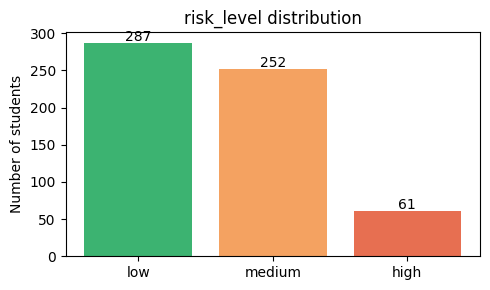

In [5]:
risk_counts = df['risk_level'].value_counts().reindex(['low', 'medium', 'high'])
print(risk_counts)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(risk_counts.index, risk_counts.values, color=['#3CB371', '#F4A261', '#E76F51'])
ax.set_title('risk_level distribution')
ax.set_ylabel('Number of students')
for i, v in enumerate(risk_counts.values):
    ax.text(i, v + 3, str(v), ha='center')
plt.tight_layout()
plt.show()

The dataset is intentionally imbalanced: most students are at low risk, a smaller share is at medium risk, and only a minority is at high risk. This matches what we observe in real vocational programmes and motivates the focus on **recall for high-risk students** later in the notebook.

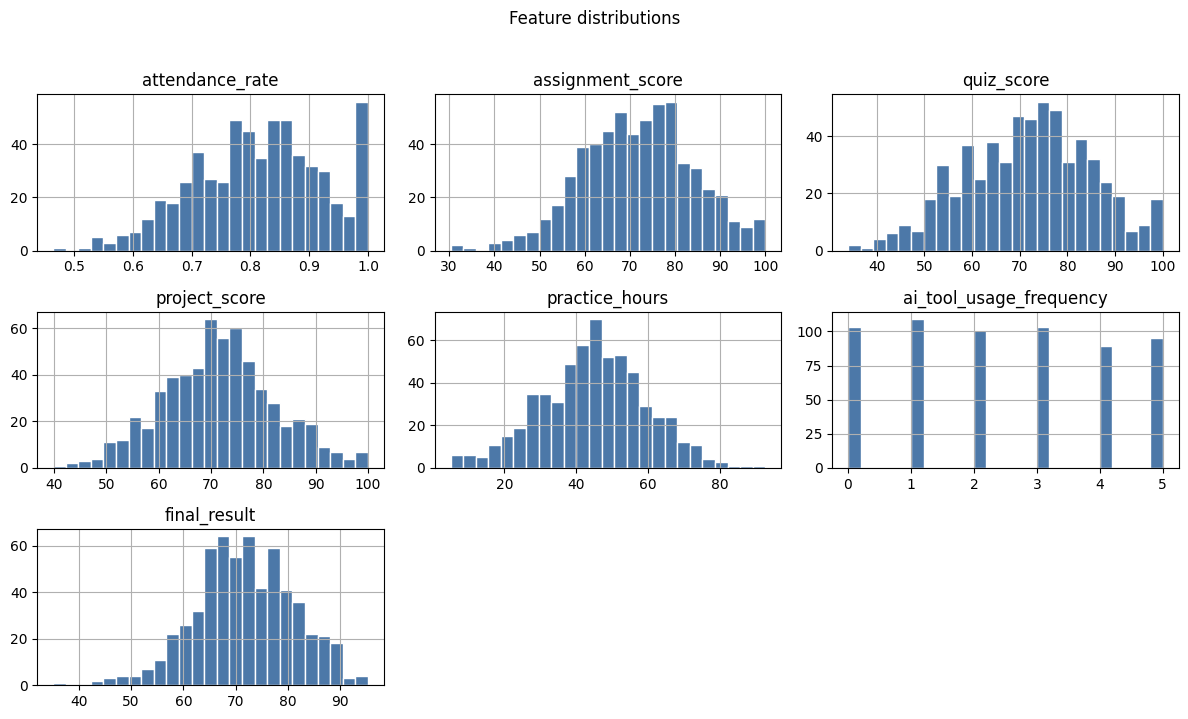

In [6]:
numeric_cols = [
    'attendance_rate', 'assignment_score', 'quiz_score',
    'project_score', 'practice_hours', 'ai_tool_usage_frequency',
    'final_result',
]
df[numeric_cols].hist(bins=25, figsize=(12, 7), color='#4C78A8', edgecolor='white')
plt.suptitle('Feature distributions', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
score_cols = ['attendance_rate', 'assignment_score', 'quiz_score', 'project_score', 'practice_hours']
df.groupby('risk_level')[score_cols].mean().reindex(['low', 'medium', 'high']).round(2)

,attendance_rate,assignment_score,quiz_score,project_score,practice_hours
risk_level,,,,,
low,0.85,79.30,78.80,78.08,47.74
medium,0.80,67.24,67.50,67.46,42.90
high,0.72,55.59,55.95,57.81,38.43


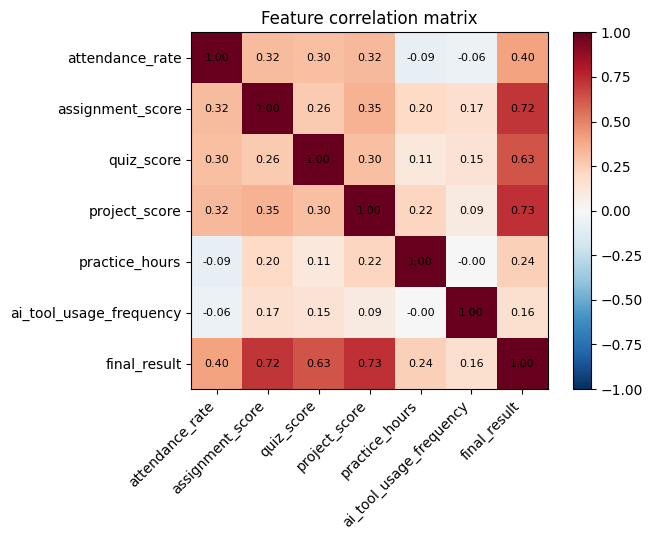

In [8]:
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

Unsurprisingly, the three coursework scores (`assignment_score`, `quiz_score`, `project_score`) are highly correlated with `final_result`. Behavioural features such as `attendance_rate` and `practice_hours` carry a weaker but still positive signal.

## 4. Model training

We predict the categorical target `risk_level` from seven features.
`final_result` is excluded from `X` because it directly defines the target and would cause **data leakage**.

In [9]:
feature_cols = [
    'attendance_rate',
    'assignment_score',
    'quiz_score',
    'project_score',
    'practice_hours',
    'ai_tool_usage_frequency',
    'previous_it_experience',
]
target_col = 'risk_level'
class_order = ['low', 'medium', 'high']

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_SEED, stratify=y,
)
print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)

Train shape: (450, 7) | Test shape: (150, 7)


In [10]:
model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 5. Evaluation

We report accuracy, macro-averaged precision/recall/F1, and a confusion matrix.
We pay extra attention to the **recall on the `high` class** because false negatives (missing a struggling student) are more costly in this context than false positives.

In [11]:
print(f"accuracy        : {accuracy_score(y_test, y_pred):.3f}")
print(f"precision_macro : {precision_score(y_test, y_pred, average='macro', zero_division=0):.3f}")
print(f"recall_macro    : {recall_score(y_test, y_pred, average='macro', zero_division=0):.3f}")
print(f"f1_macro        : {f1_score(y_test, y_pred, average='macro', zero_division=0):.3f}")
print()
print(classification_report(y_test, y_pred, labels=class_order, zero_division=0))

accuracy        : 0.833
precision_macro : 0.858
recall_macro    : 0.792
f1_macro        : 0.816

              precision    recall  f1-score   support

         low       0.91      0.82      0.86        72
      medium       0.76      0.89      0.82        63
        high       0.91      0.67      0.77        15

    accuracy                           0.83       150
   macro avg       0.86      0.79      0.82       150
weighted avg       0.84      0.83      0.83       150



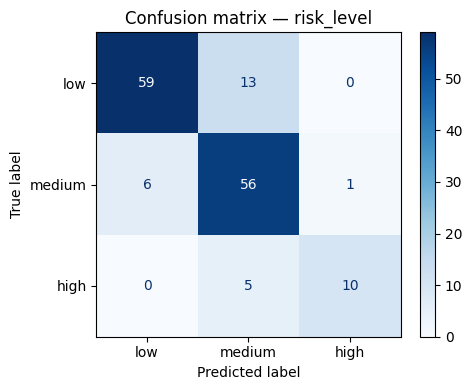

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=class_order)
disp = ConfusionMatrixDisplay(cm, display_labels=class_order)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion matrix — risk_level')
plt.tight_layout()
plt.show()

## 6. Feature importance & interpretation

Random Forest exposes `feature_importances_`, which gives a first-order, model-specific view of which features the classifier relies on. This is useful but not a causal explanation.

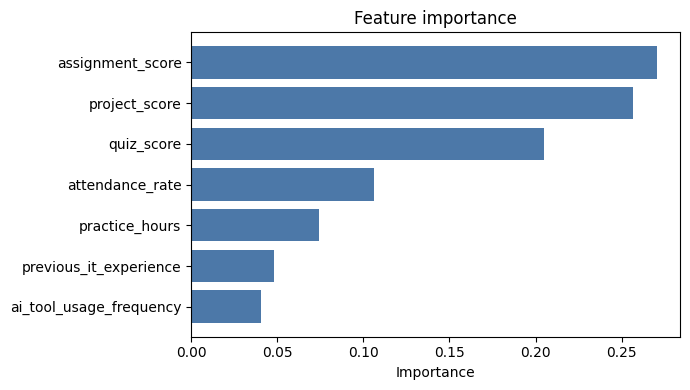

assignment_score           0.270375
project_score              0.256361
quiz_score                 0.204662
attendance_rate            0.106230
practice_hours             0.074088
previous_it_experience     0.047967
ai_tool_usage_frequency    0.040316
dtype: float64

In [13]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importances.index, importances.values, color='#4C78A8')
ax.set_xlabel('Importance')
ax.set_title('Feature importance')
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)

## 7. Conclusions for vocational IT education

Even on a small, synthetic dataset, the baseline Random Forest reaches reasonable accuracy and identifies a meaningful share of high-risk students.

**Key takeaways:**

* Coursework scores (`assignment_score`, `project_score`, `quiz_score`) carry the strongest signal — they are essentially proxies for current performance.
* Behavioural signals (`attendance_rate`, `practice_hours`) are weaker but still informative and, importantly, are available **earlier in the course** than final coursework grades.
* `ai_tool_usage_frequency` and `previous_it_experience` are weak signals on this synthetic data; their real-world effect should be studied carefully and never used to label students.

**How a teacher could use such a model:**

* As an **assistive early-warning tool**, surfacing students who may benefit from extra support.
* As a **conversation starter**, not as a hard decision rule.
* Always combined with the teacher's professional judgement and an opportunity for the student to be heard.

**What this notebook is _not_:**

* A production-ready system.
* A model trained on real students.
* A tool that should be used to filter, rank or label learners without human review.

See `SOLUTION.md` for the full discussion, including ethical considerations and future work.